# Day 22 - Underfitting and Overfitting

### Learning Objectives

After this class, students will be able to
- explain what under- and over-fitting are, and the need for train/test splits

## Theory topic: Underfitting and Overfitting

Underfitting and overfitting are universally useful concepts in ML, but it's hard to directly visualize these in the context of neural networks. Neural nets are large, complex, and high dimensional. So we're going to play with a toy problem that's easy to visualize.

Our demo problem:
- Input: a single real number
- Output: a single real number
- Fake data: a simple cubic function + Gaussian noise
- Models: polynomials of degree k (we'll try various values of k)

#### Problem setup: random data

In [1]:
# imports for the under/over-fitting demo
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

In [4]:
# Seed a random number generator.
# This is overkill, but I finally got around to looking 
# up the official "right" way to do it.
from numpy.random import MT19937
from numpy.random import RandomState, SeedSequence
rs = RandomState(MT19937(SeedSequence(123)))


###################
# data parameters #
###################
# (are fancy comment boxes like this tacky?)
n_train = 30
n_test = 50
noise_sd = 0.006

# The numpy.polynomial package has a really convenient function 
# for constructing polynomials from a list of roots.
# But it uses the opposite storage convention from polyfit and polyval.
true_model = np.polynomial.polynomial.polyfromroots([0.15, 0.35, .45, 0.9])
true_model = true_model[::-1] # reverse the list

# make the x coords of the data
x_train = np.sort(rs.uniform(0, 1, n_train))
x_test = np.sort(rs.uniform(0, 1, n_test))

# make the y coords of the data
y_train = np.polyval(true_model, x_train) + rs.normal(0, noise_sd, n_train)
y_test = np.polyval(true_model, x_test) + rs.normal(0, noise_sd, n_test)

#### Check our work:
plot the training data

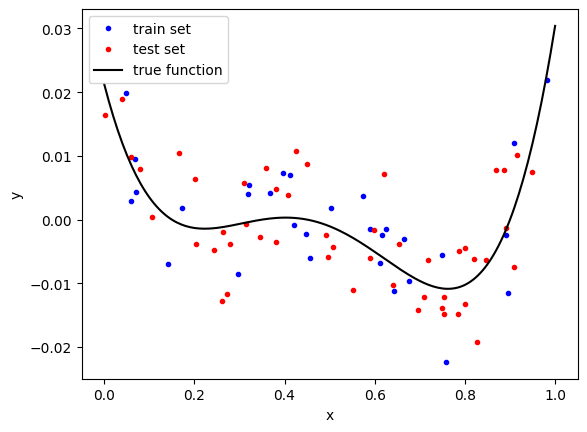

In [5]:
# Plot the model and the data
plt.plot(x_train, y_train, '.b', label='train set')
plt.plot(x_test, y_test, '.r', label='test set')

x_model = np.linspace(0, 1, 200)
y_model = np.polyval(true_model, x_model)
plt.plot(x_model, y_model, '-k', label='true function')

plt.xlabel('x')
plt.ylabel('y')
plt.legend();

#### Experiment: which model fits best?

In [8]:
def experiment(degree, ax):
    
    model = np.polyfit(x_train, y_train, degree)
    
    # Plot the model and the data
    ax.plot(x_train, y_train, '.b', label='train set')
    ax.plot(x_test, y_test, '.r', label='test set')

    x_model = np.linspace(0, 1, 200)
    y_model = np.polyval(model, x_model)
    ax.plot(x_model, y_model, '-k', label=f'degree {degree} model')

    train_errors = y_train - np.polyval(model, x_train)
    test_errors = y_test - np.polyval(model, x_test)
    train_mae = np.average(np.absolute(train_errors))
    test_mae = np.average(np.absolute(test_errors))

    perf_text = 'train mae: {:.2e}\ntest mae: {:.2e}'.format(train_mae, test_mae)
    ax.text(0.5, 0.95, perf_text,
            verticalalignment='top', horizontalalignment='center',
            transform=ax.transAxes,
            color='black', fontsize=10)

    deg_text = f'degree {degree} model'
    ax.text(0.02, 0.02, deg_text,
            verticalalignment='bottom', horizontalalignment='left',
            transform=ax.transAxes,
            color='black', fontsize=10)

    ax.set_ylim([-0.05, 0.05])
    ax.get_xaxis().set_ticks([])
    ax.get_yaxis().set_ticks([])
    #ax.set_xlabel('x')
    #ax.set_ylabel('y')
    # ax.legend();

/tmp/ipykernel_50868/640093977.py:3: RankWarning: Polyfit may be poorly conditioned
  model = np.polyfit(x_train, y_train, degree)
/tmp/ipykernel_50868/640093977.py:3: RankWarning: Polyfit may be poorly conditioned
  model = np.polyfit(x_train, y_train, degree)
/tmp/ipykernel_50868/640093977.py:3: RankWarning: Polyfit may be poorly conditioned
  model = np.polyfit(x_train, y_train, degree)
/tmp/ipykernel_50868/640093977.py:3: RankWarning: Polyfit may be poorly conditioned
  model = np.polyfit(x_train, y_train, degree)
/tmp/ipykernel_50868/640093977.py:3: RankWarning: Polyfit may be poorly conditioned
  model = np.polyfit(x_train, y_train, degree)
/tmp/ipykernel_50868/640093977.py:3: RankWarning: Polyfit may be poorly conditioned
  model = np.polyfit(x_train, y_train, degree)


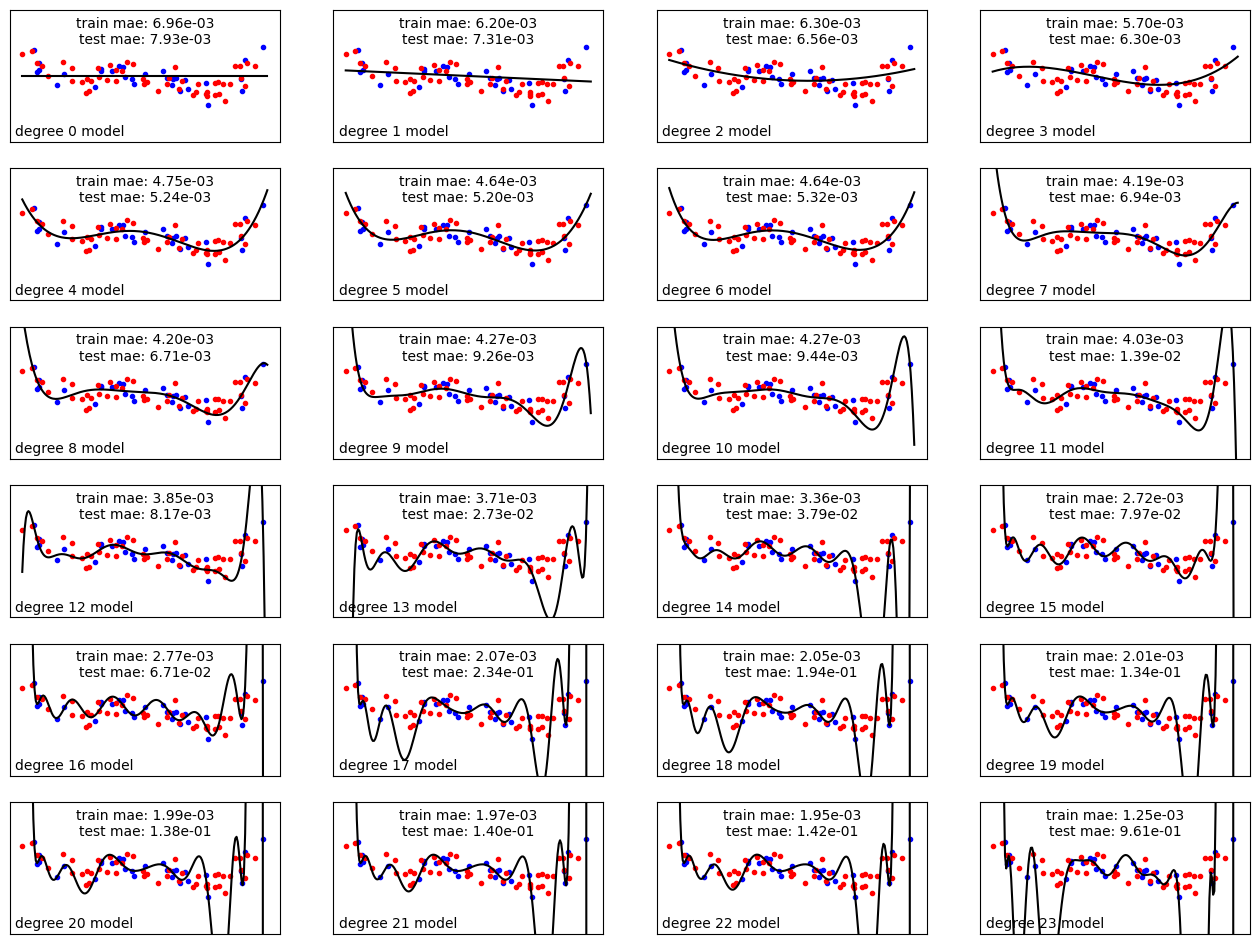

In [10]:
nrows = 6
ncols = 4
nplots = ncols * nrows
fig, axarr = plt.subplots(nrows, ncols, sharex=True, figsize=(16,12))
for degree in range(0, nplots):
    experiment(degree, axarr[degree // ncols][degree % ncols])

#### Experiment: Peformance vs Model Complexity
Redo the experiment above. But don't plot the individual models. Just plot the performance of the models.

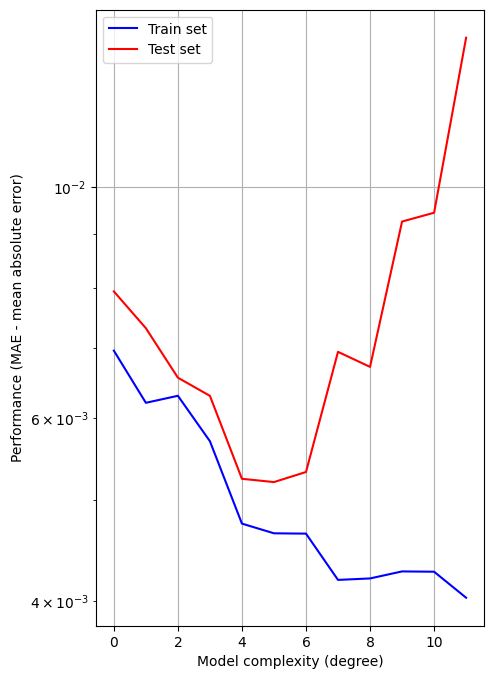

In [11]:
degrees = np.arange(0, 12)
train_mae = []
test_mae = []

for degree in degrees:
    model = np.polyfit(x_train, y_train, degree)
    
    train_errors = y_train - np.polyval(model, x_train)
    test_errors = y_test - np.polyval(model, x_test)
    train_mae.append(np.average(np.absolute(train_errors)))
    test_mae.append(np.average(np.absolute(test_errors)))

fig, ax = plt.subplots(1, 1, figsize=(5,8))
ax.plot(degrees, train_mae, '-b', label='Train set')
ax.plot(degrees, test_mae, '-r', label='Test set')

ax.set_yscale('log')
ax.grid('on')
ax.set_xlabel('Model complexity (degree)')
ax.set_ylabel('Performance (MAE - mean absolute error)')
ax.legend();

### Summary: Model Complexity

Bigger models have more parameters. They can fit more things than simple models. Training performance pretty much always improves with higher complexity, but that isn't real! When we check against the test set we see that there's a sweet spot for the right complexity, and anything more than that makes us do worse.